# ECON 4370 / BANA 4373 — Homework 4 Starter Notebook
## Difference-in-Differences: From Intuition to Estimation

**Posted:** Mar. 9  
**Due:** Mar. 23 (11:59 PM, Blackboard Ultra)

> **How to use this notebook:**
> - Replace every **TODO** with your answer (code or written response).
> - Keep written responses in **Markdown** cells. Keep code in **code** cells.
> - The notebook must run **top → bottom without errors** before you submit.
> - Save as `.ipynb` and upload to Blackboard Ultra.

---

### Context

You cannot always run a randomized experiment. When treatment is assigned by policy, geography, or circumstance rather than by a coin flip, **Difference-in-Differences (DiD)** is one of the most widely used tools for recovering a causal estimate.

In this homework you will:
1. Reconstruct the logic of DiD by hand from a 2×2 table.
2. Simulate calibrated panel data with a **known** treatment effect.
3. Estimate the DiD estimator both manually and via OLS regression.
4. Visualize the parallel trends assumption.
5. **Break the estimator** — violate parallel trends and observe the bias.
6. Apply the framework to a real policy context.

## Student Information
- **Name:** TODO
- **Section / Time:** TODO
- **NetID / Email:** TODO (optional)

---
## 0) Setup — Imports and Folder Structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import os

# Reproducibility
np.random.seed(4373)

# Folder structure (mirrors course convention)
for folder in ["data_raw", "data_clean", "exports"]:
    os.makedirs(folder, exist_ok=True)

print("Setup complete.")

Setup complete.


---
# Part 1: The DiD Logic (No Code)

Answer the following questions in your own words. Keep each answer concise (2–4 sentences unless otherwise noted).

## Question 1 — The Fundamental Problem

Briefly explain why we cannot simply compare outcomes for treated units before and after a policy to measure its causal effect. What is the key counterfactual we are missing?

**Answer:**  
We cannot identify the causal effect by looking only at treated units before and after the policy because other things may have changed over time besides the policy itself. The missing counterfactual is what the treated counties' outcomes would have been in the post period if the policy had **not** been introduced. A simple before–after comparison mixes the policy effect with any common time shocks or underlying trends.

**Instructor grading notes:** Full credit if students mention the missing counterfactual and the idea that time changes unrelated to treatment contaminate a before–after comparison.

## Question 2 — The 2×2 Table

The table below shows average employment rates (in percentage points) for two groups of counties before and after a minimum wage increase was introduced in the **treatment** group.

| | **Before** | **After** |
|---|---|---|
| **Treatment counties** | 62.0 | 65.5 |
| **Control counties** | 60.0 | 61.5 |

**(a)** What is the naïve before–after estimate for the treatment group?

**(b)** What is the control group's change over the same period?

**(c)** What is the DiD estimate? Show your arithmetic.

**(d)** Interpret the DiD estimate in a plain-English sentence. What does this number mean?

**Answer (a):**  
The naïve before–after estimate for the treatment group is:  
\[
65.5 - 62.0 = 3.5
\]

**Answer (b):**  
The control group's change is:  
\[
61.5 - 60.0 = 1.5
\]

**Answer (c):**  
The DiD estimate is:  
\[
(65.5 - 62.0) - (61.5 - 60.0) = 3.5 - 1.5 = 2.0
\]

**Answer (d):**  
The DiD estimate implies that, after netting out the change that would likely have happened anyway, the policy increased employment by about **2.0 percentage points** in the treatment counties relative to the control counties.

**Instructor grading notes:** For part (d), accept any plain-English interpretation that clearly says the treatment group's outcome rose by 2 pp *relative to the control trend*.

## Question 3 — Parallel Trends

**(a)** State the **parallel trends assumption** in your own words (1–2 sentences).

**(b)** Why can we **never fully verify** parallel trends using data alone?

**(c)** What visual evidence would make you *more* confident the assumption holds?

**Answer (a):**  
Parallel trends means that, in the absence of treatment, the treated and control groups would have followed the same average change over time. The groups do **not** need to start at the same level, but they do need to move in parallel absent the policy.

**Answer (b):**  
We can never fully verify parallel trends because we never observe the treated group's true untreated outcome after the policy. At best, we can look for evidence that the groups moved similarly **before** treatment and use institutional knowledge to argue the assumption is plausible.

**Answer (c):**  
I would be more confident if the two groups showed similar slopes in multiple pre-treatment periods and if there were no obvious shocks affecting only one group right before treatment.

**Instructor grading notes:** Students do not need perfect wording. Core ideas: same untreated trend, untestable counterfactual, pre-trend evidence helps but does not prove it.

## Question 4 — Selection Bias Link

Recall the **SDO decomposition** from the potential outcomes lecture:

$$\text{SDO} = \text{ATE} + \underbrace{E[Y_i(0)|D_i=1] - E[Y_i(0)|D_i=0]}_{\text{Selection Bias}}$$

Explain in 2–3 sentences how DiD attempts to remove the selection bias term. What is it using the control group's trend to do?

**Answer:**  
DiD tries to remove selection bias that is **constant over time** by differencing out baseline level differences between treated and control groups. It uses the control group's change over time to approximate what would have happened to the treated group in the absence of treatment. In other words, the control group's trend is used to build the missing counterfactual change in \(Y(0)\) for the treated units.

**Instructor grading notes:** Full credit if they say DiD removes fixed baseline differences and uses the control trend as the counterfactual for the treated group's untreated path.

---
# Part 2: Simulating Panel Data with a Known Treatment Effect

You will now generate a **calibrated synthetic dataset** where we know the true causal effect. This lets you check whether your estimator recovers it.

### Context

Imagine a state job-training program rolled out in **Year 2** for a subset of counties. You observe each county in **Year 1** (pre-policy) and **Year 2** (post-policy). The outcome is the county-level employment rate (percentage points).

**Design parameters (do not change):**
- `N_counties = 200` — 100 treatment, 100 control
- `TRUE_ATT = 4.0` — the true causal effect (pp) you want to recover
- Treatment counties have a **higher baseline** employment rate (selection bias built in)
- Both groups share the **same time trend** (parallel trends holds by construction)

## Question 5 — Write Your Prior

**Before running any code**, answer the following:

**(a)** If you ignored the control group and only compared treatment counties before vs. after, would you expect to *over-estimate*, *under-estimate*, or *correctly estimate* the true effect of 4.0 pp? Why?

**(b)** If you used a cross-sectional comparison (treatment vs. control *only in Year 2*), would selection bias push your estimate up or down relative to the truth? Why?

**Prior (a):**  
I would expect the treated-only before–after estimate to **over-estimate** the policy effect. The treated group gets the true ATT of 4.0 pp, but it also experiences the common +2.0 pp time trend, so a before–after comparison should pick up both.

**Prior (b):**  
The cross-sectional comparison in Year 2 should also be biased **upward** relative to the truth because treatment counties start out 5 pp higher at baseline due to selection bias. Comparing the groups only after treatment mixes the true effect with that pre-existing advantage.

**Instructor grading notes:** The key directional predictions are “upward” for both parts, but students should justify each one differently: common time trend in (a), baseline selection bias in (b).

## Question 6 — Simulate the Data

In [2]:
# ── Design parameters ──────────────────────────────────────────────────────
N_treat   = 100
N_control = 100
TRUE_ATT  = 4.0          # pp — the number we want to recover
COMMON_TREND = 2.0       # pp — shared time trend (same for both groups)
SELECTION_BIAS = 5.0     # pp — treatment counties start higher at baseline
NOISE_SD  = 3.0          # pp — county-level noise

# ── Build long-format panel ─────────────────────────────────────────────────
county_id  = list(range(N_treat + N_control))
treated    = [1] * N_treat + [0] * N_control

# Baseline (Year 1) employment rates
baseline_treat   = 62.0 + SELECTION_BIAS
baseline_control = 62.0

# County fixed effects (stable characteristic that shifts each county's baseline)
county_fe = np.concatenate([
    np.random.normal(baseline_treat,   NOISE_SD, N_treat),
    np.random.normal(baseline_control, NOISE_SD, N_control)
])

rows = []
for cid, treat, fe in zip(county_id, treated, county_fe):
    for year in [1, 2]:
        post = 1 if year == 2 else 0
        treatment_effect = TRUE_ATT if (post == 1 and treat == 1) else 0.0
        noise = np.random.normal(0, NOISE_SD)
        emp_rate = fe + COMMON_TREND * post + treatment_effect + noise
        rows.append({"county": cid, "year": year, "post": post,
                     "treated": treat, "emp_rate": emp_rate})

df = pd.DataFrame(rows)

# Save raw data
df.to_csv("data_raw/panel_simulated.csv", index=False)
print(f"Dataset shape: {df.shape}")
df.head(8)

Dataset shape: (400, 5)


,county,year,post,treated,emp_rate
0,0,1,0,1,68.480374
1,0,2,1,1,72.942196
2,1,1,0,1,70.626987
3,1,2,1,1,71.783893
4,2,1,0,1,65.092845
5,2,2,1,1,72.665682
6,3,1,0,1,72.921958
7,3,2,1,1,69.864334


**Briefly describe the dataset (2–3 sentences):** What does each row represent? How many rows are there total, and why?

**Answer:**  
Each row represents one county-year observation: a specific county observed either before or after the policy. There are **400 rows** total because there are 200 counties altogether (100 treated and 100 control), and each county appears in two years. So the dataset is a balanced two-period panel.

**Instructor grading notes:** Full credit if they identify one row as a county-year and explain 200 counties × 2 years = 400 observations.

---
# Part 3: Naïve Estimates vs. DiD (Manual Calculation)

## Question 7 — Reconstruct the 2×2 Table

**Clarifying prompt (so you do not get stuck on pandas):**

You are trying to recover the four cell means in the 2×2 DiD table. A very direct way is to group by `treated` and `post`, then take the mean of `emp_rate`.

**Hint (you may use this directly):**
```python
df.groupby(["treated", "post"])["emp_rate"].mean()
```

Once you see the four means, store them in:
`treat_pre`, `treat_post`, `ctrl_pre`, `ctrl_post`.

In [3]:
# Compute the mean employment rate for each of the 4 cells:
#   (treated=1, post=0), (treated=1, post=1),
#   (treated=0, post=0), (treated=0, post=1)

treat_pre = df.loc[(df["treated"] == 1) & (df["post"] == 0), "emp_rate"].mean()
treat_post = df.loc[(df["treated"] == 1) & (df["post"] == 1), "emp_rate"].mean()
ctrl_pre = df.loc[(df["treated"] == 0) & (df["post"] == 0), "emp_rate"].mean()
ctrl_post = df.loc[(df["treated"] == 0) & (df["post"] == 1), "emp_rate"].mean()

print(f"Treated   | Before: {treat_pre:.2f}  After: {treat_post:.2f}")
print(f"Control   | Before: {ctrl_pre:.2f}  After: {ctrl_post:.2f}")

Treated   | Before: 67.41  After: 72.55
Control   | Before: 61.55  After: 64.33


## Question 8 — Three Estimators, Three Answers

**Clarifying prompt:**

Use the four means from Question 7. You do **not** need any new pandas work here.

Mechanically:
- Before–after for treated only = treated after − treated before
- Cross-section in post period = treated post − control post
- DiD = (treated after − treated before) − (control after − control before)

In [4]:
# Compute the three estimators below and print them.

# 1. Naïve before–after for treated group only
naive_before_after = treat_post - treat_pre

# 2. Cross-sectional comparison (treated vs. control in post period only)
naive_cross_section = treat_post - ctrl_post

# 3. Difference-in-Differences estimator
did_manual = (treat_post - treat_pre) - (ctrl_post - ctrl_pre)

print(f"True ATT               : {TRUE_ATT:.2f}")
print(f"Naïve before-after     : {naive_before_after:.2f}")
print(f"Naïve cross-section    : {naive_cross_section:.2f}")
print(f"DiD (manual)           : {did_manual:.2f}")

True ATT               : 4.00
Naïve before-after     : 5.14
Naïve cross-section    : 8.22
DiD (manual)           : 2.35


**Answer:**  
The manual DiD estimate comes closest to the true ATT. In this simulation, the DiD estimate is about **2.35 pp**, while the true ATT is 4.0 pp. The treated-only before–after estimate is too high because it picks up both the policy effect and the common time trend, and the post-period cross-sectional estimate is too high because it also includes the baseline selection advantage of treatment counties. The DiD estimator removes both the common time shock and the fixed baseline difference, although sampling noise keeps it from landing exactly on 4.0.

**Instructor grading notes:** Students should identify DiD as best. Small differences in wording are fine as long as they correctly explain the biases in the two naïve estimators.

**Answer:** TODO

---
# Part 4: DiD via OLS Regression

The DiD estimator has an exact OLS representation. The regression we want is:

$$\text{emp\_rate}_{it} = \beta_0 + \beta_1 \cdot \text{post}_t + \beta_2 \cdot \text{treated}_i + \beta_3 \cdot (\text{post}_t \times \text{treated}_i) + \varepsilon_{it}$$

where $\hat{\beta}_3$ is the **DiD estimator**.

## Question 9 — Write Your Prior for β₃

Before running the regression, write down what you expect for $\hat{\beta}_3$ and why.

**Prior:**  
I expect \(\hat{\beta}_3\) to be close to the manual DiD estimate from Question 8, because in the standard two-group/two-period setup the interaction coefficient is the DiD estimator. So I expect it to be close to the true ATT of 4.0 pp, but not necessarily exact because the data include random noise.

**Instructor grading notes:** Full credit if they say \(\beta_3\) is the DiD effect / interaction term and should be close to 4.

## Question 10 — Run the DiD Regression

**Clarifying prompt:**

In regression form, DiD is just:
\[
Y = \beta_0 + \beta_1 \text{post} + \beta_2 \text{treated} + \beta_3 (\text{post} \times \text{treated}) + u
\]

A simple way to code the interaction is:
```python
df["post_x_treated"] = df["post"] * df["treated"]
```

Then run OLS with `emp_rate` as the outcome.

In [5]:
# Create the interaction term and run the OLS model.

df["post_x_treated"] = df["post"] * df["treated"]

model = smf.ols("emp_rate ~ post + treated + post_x_treated", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               emp_rate   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     137.1
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           6.23e-61
Time:                        10:43:44   Log-Likelihood:                -1122.7
No. Observations:                 400   AIC:                             2253.
Df Residuals:                     396   BIC:                             2269.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         61.5473      0.403    152.

**Question 10a — Coefficient Interpretation:** In plain English, interpret each of the four coefficients ($\hat{\beta}_0$, $\hat{\beta}_1$, $\hat{\beta}_2$, $\hat{\beta}_3$). What does each one represent in the real-world context of this dataset?

**β̂₀ (intercept):**  
\(\hat{\beta}_0 \approx 61.55\). This is the average employment rate for the **control group before the policy**.

**β̂₁ (post):**  
\(\hat{\beta}_1 \approx 2.79\). This is the change from before to after for the **control group**, capturing the common time trend.

**β̂₂ (treated):**  
\(\hat{\beta}_2 \approx 5.87\). This is the baseline difference between the treated and control groups **before** the policy.

**β̂₃ (interaction):**  
\(\hat{\beta}_3 \approx 2.35\). This is the DiD estimate: the additional post-period change for the treated group beyond the control group's change.

**Instructor grading notes:** This is the main mapping students need to know. Minor wording differences are fine as long as the baseline group is clearly identified.

**Question 10b:** Does $\hat{\beta}_3$ match your manual DiD calculation from Question 8? Does it match the true ATT (4.0 pp)? Why might it not be exactly 4.0?

**Answer:**  
Yes, \(\hat{\beta}_3\) matches the manual DiD calculation from Question 8; both are about **2.35 pp**. It does **not** exactly match the true ATT of 4.0 pp because this is a finite simulated sample with random noise at both the county and year level. In expectation, DiD should recover the true effect under parallel trends, but any single realization can be somewhat above or below the truth.

**Instructor grading notes:** Students should explicitly say β3 equals the manual DiD. They should also mention random sampling noise / finite-sample variation as the reason it is not exactly 4.

---
# Part 5: Visualizing Parallel Trends

## Question 11 — The Parallel Trends Plot

**Clarifying prompt:**

First create a small summary dataset with the mean employment rate by `year` and `treated`. Then plot the two series.

**Hint (one possible approach):**
```python
means = df.groupby(["year", "treated"], as_index=False)["emp_rate"].mean()
```
Then plot one line for `treated == 1` and one line for `treated == 0`.

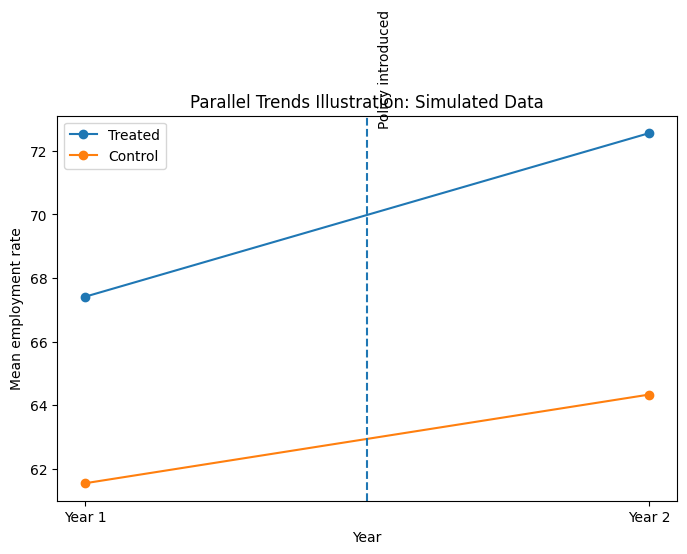

Figure saved.


In [6]:
# Create a line plot showing the mean employment rate by year
# for treated and control groups separately.

means_plot = (
    df.groupby(["treated", "year"], as_index=False)["emp_rate"]
      .mean()
)

treated_plot = means_plot[means_plot["treated"] == 1]
control_plot = means_plot[means_plot["treated"] == 0]

plt.figure(figsize=(8, 5))
plt.plot(treated_plot["year"], treated_plot["emp_rate"], marker="o", label="Treated")
plt.plot(control_plot["year"], control_plot["emp_rate"], marker="o", label="Control")
plt.axvline(x=1.5, linestyle="--")
plt.text(1.52, max(means_plot["emp_rate"]) + 0.15, "Policy introduced", rotation=90, va="bottom")
plt.xticks([1, 2], ["Year 1", "Year 2"])
plt.xlabel("Year")
plt.ylabel("Mean employment rate")
plt.title("Parallel Trends Illustration: Simulated Data")
plt.legend()
plt.savefig("exports/parallel_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

**Describe your plot (2–3 sentences):** Does the visual evidence support the parallel trends assumption *before* the policy? What does the gap between the two lines in Year 2 suggest?

**Answer:**  
The plot is consistent with the parallel trends idea in the sense that the treated and control groups move upward together from Year 1 to Year 2, aside from the treatment effect in the treated group after the policy. The two lines start at different levels, but that is allowed under DiD; what matters is the counterfactual change, not equal baselines. The larger gap in Year 2 suggests that the treated group experiences an additional increase beyond the shared time trend.

**Instructor grading notes:** Because there are only two periods, students cannot literally verify pre-trends from multiple pre-periods. Give credit if they note this limitation and still interpret the picture correctly.

---
# Part 6: Break the Estimator — Violating Parallel Trends

> *"The best way to understand an assumption is to violate it on purpose."*

Now you will **deliberately break** the parallel trends assumption by introducing a pre-existing trend that differs across groups. This lets you see exactly how and how much the DiD estimator goes wrong.

## Question 12 — Write Your Prior Before Breaking

You are about to add an extra +3 pp trend to the treatment group *before* the policy (i.e., they were already trending upward more steeply). The true ATT remains 4.0 pp.

Before running the code: in which direction do you expect the **biased** DiD estimate to move (higher or lower than 4.0)? Why?

**Prior:**  
I expect the biased DiD estimate to move **higher** than 4.0. If the treatment group was already rising faster even without the policy, then DiD will mistakenly attribute part of that extra upward trend to the treatment effect.

**Instructor grading notes:** The directional prediction should be upward. Students should connect the extra treated-group trend to omitted counterfactual growth.

In [7]:
# ── Simulate broken data: treatment group has a steeper pre-trend ───────────
EXTRA_TREAT_TREND = 3.0   # pp — treatment group was already rising faster

rows_broken = []
for cid, treat, fe in zip(county_id, treated, county_fe):
    for year in [1, 2]:
        post = 1 if year == 2 else 0
        treatment_effect = TRUE_ATT if (post == 1 and treat == 1) else 0.0
        # Extra trend: treatment group trends up MORE even without the policy
        extra_trend = EXTRA_TREAT_TREND * post * treat
        noise = np.random.normal(0, NOISE_SD)
        emp_rate = fe + COMMON_TREND * post + extra_trend + treatment_effect + noise
        rows_broken.append({"county": cid, "year": year, "post": post,
                             "treated": treat, "emp_rate": emp_rate})

df_broken = pd.DataFrame(rows_broken)
df_broken["post_x_treated"] = df_broken["post"] * df_broken["treated"]

# Estimate DiD on the broken data
model_broken = smf.ols("emp_rate ~ post + treated + post_x_treated", data=df_broken).fit()

biased_estimate = model_broken.params["post_x_treated"]
print(f"True ATT        : {TRUE_ATT:.2f}")
print(f"Biased estimate : {biased_estimate:.2f}")
print(f"Bias            : {biased_estimate - TRUE_ATT:.2f} pp")

True ATT        : 4.00
Biased estimate : 6.62
Bias            : 2.62 pp


**Interpret the result (3–4 sentences):** Was the bias in the direction you predicted? Explain *mechanically* why the DiD estimator picks up the extra trend as part of the treatment effect. What would an applied economist need to rule this out?

**Answer:**  
Yes, the bias goes in the predicted direction. The estimated DiD effect rises to about **6.62 pp**, which is above the true ATT of 4.0 pp by roughly **2.62 pp**. Mechanically, DiD interprets the treated group's extra rise as if it were caused by the policy, because it uses the control group's flatter trend as the counterfactual. An applied economist would need evidence that no differential pre-trend existed—ideally several pre-treatment periods, institutional knowledge, or alternative specifications that probe this threat.

**Instructor grading notes:** The core idea is that DiD loads the pre-existing treated-group trend onto β3 when parallel trends fails.

## Question 13 — Plot the Broken Parallel Trends

**Clarifying prompt:**

You can reuse the same plotting logic from Question 11, but do it twice:
- once using `df`
- once using `df_broken`

A simple first step is:
```python
means_orig = df.groupby(["year", "treated"], as_index=False)["emp_rate"].mean()
means_broken = df_broken.groupby(["year", "treated"], as_index=False)["emp_rate"].mean()
```
Then plot them in two side-by-side panels.

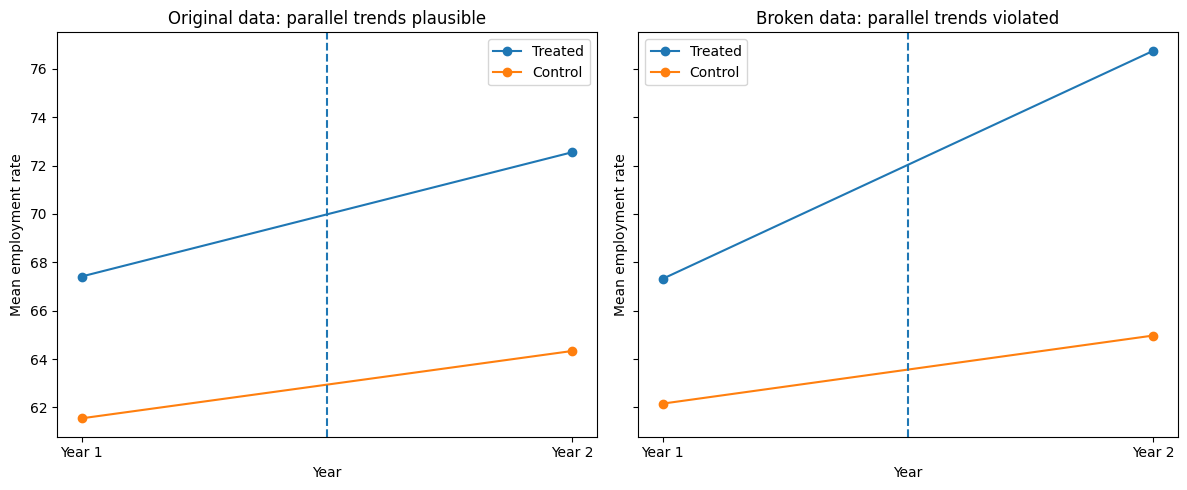

In [8]:
# Reproduce the parallel trends plot using df_broken.
# Side-by-side subplots (1 row, 2 cols).

means_original = df.groupby(["treated", "year"], as_index=False)["emp_rate"].mean()
means_broken = df_broken.groupby(["treated", "year"], as_index=False)["emp_rate"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, data, title in zip(
    axes,
    [means_original, means_broken],
    ["Original data: parallel trends plausible", "Broken data: parallel trends violated"]
):
    treated_data = data[data["treated"] == 1]
    control_data = data[data["treated"] == 0]
    ax.plot(treated_data["year"], treated_data["emp_rate"], marker="o", label="Treated")
    ax.plot(control_data["year"], control_data["emp_rate"], marker="o", label="Control")
    ax.axvline(x=1.5, linestyle="--")
    ax.set_xticks([1, 2], ["Year 1", "Year 2"])
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean employment rate")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("exports/parallel_trends_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Describe what you see (2–3 sentences):** What is the visual difference between the two panels? How does this plot demonstrate the importance of the parallel trends assumption for the validity of the DiD estimator?

**Answer:**  
In the left panel, the treated and control groups differ in level but move in roughly parallel fashion, so the post-period divergence can plausibly be attributed to treatment. In the right panel, the treated group is visibly rising faster, so the extra gap after treatment is no longer clean evidence of a policy effect. The comparison makes clear that DiD is only credible when the control group's trend is a good stand-in for the treated group's untreated trend.

**Instructor grading notes:** Full credit if they contrast level differences versus slope differences and link the slope difference to invalid counterfactual construction.

---
# Part 7: Real-World Application — Card & Krueger (1994)

Card and Krueger (1994) used DiD to study the effect of New Jersey's 1992 minimum wage increase on fast-food employment. New Jersey raised its minimum wage from \$4.25 to \$5.05; neighboring Pennsylvania did not. The table below reports their famous "Table 3" estimates (in full-time equivalent (FTE) employees per store):

| | **Before (Feb. 1992)** | **After (Nov. 1992)** | **Δ (After − Before)** |
|---|---|---|---|
| **New Jersey (treatment)** | 20.44 | 21.03 | +0.59 |
| **Pennsylvania (control)** | 23.33 | 21.17 | −2.16 |

Source: Card & Krueger (1994), *American Economic Review*, Table 3.

## Question 14 — Replicate the DiD Estimate

In [9]:
# Using the four values in the table above, compute
#   (a) the DiD estimate (as Card & Krueger report it)
#   (b) what NJ's employment would have been under the counterfactual
#       (i.e., if it had followed Pennsylvania's trend)

nj_before = 20.44
nj_after  = 21.03
pa_before = 23.33
pa_after  = 21.17

ck_did = (nj_after - nj_before) - (pa_after - pa_before)
nj_counterfactual = nj_before + (pa_after - pa_before)

print(f"Card–Krueger DiD estimate : {ck_did:.2f} FTE")
print(f"NJ counterfactual (post)  : {nj_counterfactual:.2f} FTE")

Card–Krueger DiD estimate : 2.75 FTE
NJ counterfactual (post)  : 18.28 FTE


**Answer:**  
The Card–Krueger DiD estimate implies that fast-food employment in New Jersey rose by about **2.75 full-time-equivalent workers per restaurant** relative to what we would have expected based on Pennsylvania's trend. That was surprising because the standard textbook prediction at the time was that a higher minimum wage should reduce employment. Pennsylvania plays the role of the control group: its change over time provides the counterfactual trend for New Jersey absent the policy. So the key claim is not that New Jersey employment rose absolutely, but that it rose relative to the comparison state's trend.

**Instructor grading notes:** Students do not need to know the broader literature, but they should understand why the result was seen as surprising and what PA contributes to identification.

**Answer:** TODO

## Question 15 — Threats to Identification

List **two** specific threats to the validity of the Card–Krueger DiD estimate. For each threat:
- Describe what would have to happen in the real world for it to be a problem.
- State whether it would bias the estimate **upward** or **downward** relative to the true effect.

**Threat 1:**  
A simultaneous positive shock specific to New Jersey's fast-food sector—for example, stronger local demand growth or tourism—could make employment rise there even without the minimum wage increase. That would bias the estimate **upward**, because DiD would attribute some of that extra New Jersey-specific growth to the policy.

**Threat 2:**  
If Pennsylvania was a bad control because its fast-food labor market was hit by a negative shock during the same period, the control trend would be too weak. That would also tend to bias the DiD estimate **upward**, since New Jersey would look unusually strong relative to a depressed comparison group.

**Instructor grading notes:** Accept other reasonable threats too, such as spillovers across the border, measurement error, composition changes, or anticipation. What matters is whether students clearly describe the mechanism and the direction of bias.

---
# Part 8: Extension — How Robust is the Estimate? (Code + Interpretation)

## Question 16 — Sensitivity to Noise

Go back to the original simulated dataset. Re-run the simulation **50 times** (each time with a different random seed), saving the $\hat{\beta}_3$ from each run. Then:

**(a)** Plot a histogram of the 50 estimates.  
**(b)** Mark the true ATT (4.0 pp) with a vertical dashed line.  
**(c)** Report the mean and standard deviation of the 50 estimates.

**Clarifying prompt:**

The goal here is not new econometrics. It is repetition.

For each seed:
1. Recreate the simulated panel exactly as in Question 6, but with that seed.
2. Run the same DiD regression as in Question 10.
3. Append the interaction coefficient, `model.params["post_x_treated"]`, to `estimates`.

If helpful, you can copy your code from Question 6 and Question 10 and only change the seed inside the loop.

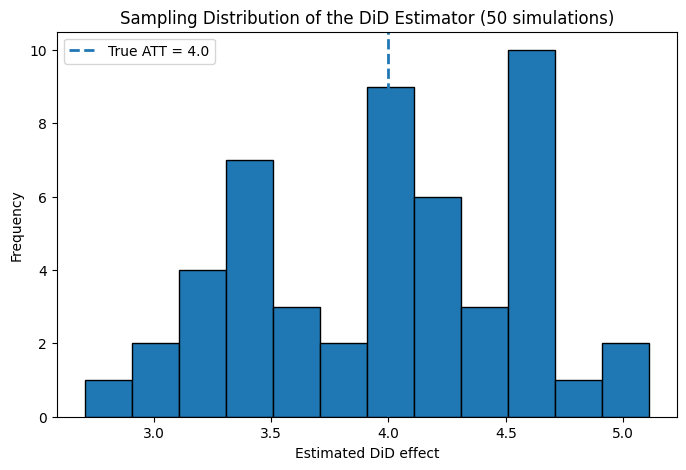

Mean of estimates : 3.99
Std of estimates  : 0.57


In [10]:
estimates = []

for seed in range(50):
    np.random.seed(seed)

    county_id = list(range(N_treat + N_control))
    treated = [1] * N_treat + [0] * N_control

    county_fe = np.concatenate([
        np.random.normal(baseline_treat,   NOISE_SD, N_treat),
        np.random.normal(baseline_control, NOISE_SD, N_control)
    ])

    rows = []
    for cid, treat, fe in zip(county_id, treated, county_fe):
        for year in [1, 2]:
            post = 1 if year == 2 else 0
            treatment_effect = TRUE_ATT if (post == 1 and treat == 1) else 0.0
            noise = np.random.normal(0, NOISE_SD)
            emp_rate = fe + COMMON_TREND * post + treatment_effect + noise
            rows.append({
                "county": cid,
                "year": year,
                "post": post,
                "treated": treat,
                "emp_rate": emp_rate
            })

    df_sim = pd.DataFrame(rows)
    df_sim["post_x_treated"] = df_sim["post"] * df_sim["treated"]

    model_sim = smf.ols("emp_rate ~ post + treated + post_x_treated", data=df_sim).fit()
    estimates.append(model_sim.params["post_x_treated"])

estimates = np.array(estimates)

plt.figure(figsize=(8, 5))
plt.hist(estimates, bins=12, edgecolor="black")
plt.axvline(TRUE_ATT, linestyle="--", linewidth=2, label=f"True ATT = {TRUE_ATT:.1f}")
plt.xlabel("Estimated DiD effect")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of the DiD Estimator (50 simulations)")
plt.legend()
plt.savefig("exports/did_estimates_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean of estimates : {estimates.mean():.2f}")
print(f"Std of estimates  : {estimates.std():.2f}")

**Interpret (2–3 sentences):** Is the DiD estimator *unbiased* (centered near 4.0)? What does the spread of the distribution tell you about uncertainty when applying DiD to real data?

**Answer:**  
Across repeated simulations, the DiD estimator appears approximately unbiased because the distribution is centered very close to the true ATT of 4.0. The spread of the estimates shows that even when the design is valid, any one sample can produce a noticeably different number just because of noise. In real data, that sampling variability is one reason we need standard errors, confidence intervals, and humility in interpretation.

**Instructor grading notes:** Full credit if they distinguish unbiasedness (centered at truth) from precision (tightness / spread of estimates).

---
# Part 9: Reflection

## Question 17 — Explain DiD to a Policymaker

Imagine a policymaker asks: *“What does Difference-in-Differences actually do, and why should I trust it more than a simple before–after comparison?”*

Write a **3–5 sentence** response in plain English. Avoid jargon. Your explanation should mention:
- why a before–after comparison can be misleading,
- what role the control group plays,
- and why parallel trends matters.

**Answer:**  
A simple before–after comparison can be misleading because many things besides the policy may change over time, like the economy or local demand. Difference-in-Differences improves on that by comparing the treated group to a similar untreated group over the same period, so we can subtract out changes that would have happened anyway. The control group is there to show the likely path of the treated group if the policy had never happened. This works only if the two groups were moving in similar ways beforehand, which is why the parallel trends assumption is so important.

**Instructor grading notes:** Give credit for a plain-English explanation that includes the three required ingredients, even if students avoid the exact phrase “parallel trends.”

## Question 18 — Synthesis (6–8 sentences)

Reflect on the following:

1. What makes DiD more convincing than a simple before–after comparison?
2. In what situations would you *not* trust a DiD estimate, even if the parallel trends plot looks good?
3. How does the simulation exercise (knowing the true ATT) help you build intuition that you cannot get from real data alone?

**Reflection:**  
DiD is more convincing than a simple before–after comparison because it uses a control group to net out changes over time that are unrelated to the policy. That gives us a more credible counterfactual than just looking at the treated group alone. I would still be cautious about a DiD estimate if the treated and control groups were affected by different shocks, if there were spillovers between them, if composition changed sharply over time, or if the policy was anticipated and behavior adjusted before treatment. Even a good-looking plot cannot rule out every threat, especially when there are only a few pre-periods. The simulation is helpful because we know the true ATT, so we can see directly when DiD works and when it fails. Real data never let us observe that truth, which is why simulation is such a powerful teaching tool. Seeing bias emerge when parallel trends is broken also makes the identifying assumption much more concrete than a purely verbal definition.

**Instructor grading notes:** This is a synthesis question. Reward clear integration of identification, assumptions, and the value of simulation rather than any single “correct” phrasing.

---
## Final Export

In [11]:
# Save the cleaned panel to data_clean/
df.to_csv("data_clean/panel_clean.csv", index=False)
print("Clean data saved to data_clean/panel_clean.csv")
print("\nExports folder contents:")
for f in sorted(os.listdir("exports")):
    print(" ", f)

Clean data saved to data_clean/panel_clean.csv

Exports folder contents:
  did_estimates_histogram.png
  parallel_trends.png
  parallel_trends_comparison.png


---
## Submission Checklist

Before uploading to Blackboard, confirm:

- [ ] Notebook runs **top → bottom without errors**
- [ ] Every **TODO** replaced with a real answer
- [ ] Both figures saved in `exports/` (parallel trends + comparison)
- [ ] Written answers are in **Markdown cells** (not code comments)
- [ ] Saved as **`.ipynb`** and uploaded to Blackboard Ultra

---
### Further Reading (Optional)
- **Cunningham (2021)**, *Causal Inference: The Mixtape*, Ch. 9 (DiD) — free at [mixtape.scunning.com](https://mixtape.scunning.com)  
- **Card & Krueger (1994)**, "Minimum Wages and Employment," *American Economic Review*  
- **Angrist & Pischke (2009)**, *Mostly Harmless Econometrics*, Ch. 5